# HW2 - Applied Quantitative Logistics

Instruction for submission:

- Please create a private GitHub repository then commit your solution to your repository.

- Deadline: **March 8, 2025, 11:59 pm.**

- Please replace **Your_Name** by your full-name : **[HW2_AQL]-YOUR_NAME**


## Tasks:

1. Implement Roulette Wheel Selection (1 point)
2. Implement Tournoment Selection (1 point)
3. Implement Scenario 1 for Genetic Engineering Algorithm (namely GEA_1) (1 point)
4. Implement Scenario 2 for Genetic Engineering Algorithm (namely GEA_2) (1 point)
5. Implement Scenario 3 for Genetic Engineering Algorithm (namely GEA_3) (1 point)
6. By elements 3, 4, 5, make 5 different algorithms and compare the results of all methods on a same cost function, then plot all minimization curves on a single line plot. (2 points)

Algorithms:
1. Genetic Algorithm (GA) - contains only Crossover and Mutation operators
2. Genetic Engineering Algorithm (GEA_1) - contains scenario 1 in addition to GA
3. Genetic Engineering Algorithm (GEA_2) - contains scenario 2 in addition to GA
4. Genetic Engineering Algorithm (GEA_3) - contains scenario 3 in addition to GA
4. Genetic Engineering Algorithm (GEA full-scenarios) - contains all operators (Crossover, Mutation, Scenario 1, Scenario 2, Scenario 3)

For more details about the Genetic Engineering Algorithm (GEA), please refer to the original paper: https://link.springer.com/article/10.1134/S000511792403007X

### After the assigment is done, please, push it to a [private GitHub repository](https://docs.github.com/en/github/administering-a-repository/managing-repository-settings/setting-repository-visibility) and invite [Majid-Sohrabi](https://github.com/Majid-Sohrabi) [as collaborators](https://docs.github.com/en/account-and-profile/setting-up-and-managing-your-github-user-account/managing-access-to-your-personal-repositories/inviting-collaborators-to-a-personal-repository).

## Implementing Genetic Algorithm for *Continuous Problems*

## Continuous GA

**Problem:** Sphere
$$
\min{z} = f_{sph}(x) = \begin{equation*}
 \sum_{i=1}^n {x_i}^2 \end{equation*}
$$

$$
x_{min} \le x_i \le x_{max}
$$

Optimal Solutions:

$$
\forall i \;
\left\{
    \begin{array}\\
        x_i^* = 0 \\
        z^* = 0 \\
    \end{array}
\right.
$$

In [63]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt

### Cost Function

In [64]:
def sphere(x):

    global NFE

    if pd.isna(NFE):
        NFE = 0

    NFE += 1

    z = [item**2 for item in x]

    return sum(z)

In [65]:
def pop_sort(p, c):

    li = [[c[i], i] for i in range(len(c))]
    li.sort()

    sorted_index = [x[1] for x in li]

    sorted_pop = [p[i] for i in sorted_index]
    sorted_cost = [c[i] for i in sorted_index]

    return sorted_pop, sorted_cost

### CrossOver

In [66]:
def CrossOver(x1, x2, gamma, varMin, varMax):

    alpha = list(np.random.uniform(-gamma, 1+gamma, size=len(x1)))

    y1 = list(np.multiply(alpha, x1) + (1 - np.array(alpha))*np.array(x2))
    y2 = list(np.multiply(alpha, x2) + (1 - np.array(alpha))*np.array(x1))

    y1 = [max(i, varMin) for i in y1]
    y1 = [min(i, varMax) for i in y1]

    y2 = [max(i, varMin) for i in y2]
    y2 = [min(i, varMax) for i in y2]

    return y1, y2

### Mutation

In [67]:
def mutation(x, varMin, varMax):
    index = int(np.random.randint(0, len(x), size=1))

    sigma = 0.1 * (varMax-varMin)

    y = x.copy()

    y[index] = x[index] + sigma*np.random.randn()

    y = [max(i, varMin) for i in y]
    y = [min(i, varMax) for i in y]
    return y

## How to more improve the Genetic Algorithm

Parent selection can be an option.

### Roulette Wheel Selection

In [68]:
import numpy as np

def roulette_wheel_selection(population, costs, beta, worst_cost):

    normalized_costs = [cost / worst_cost for cost in costs]
    fitness = [np.exp(-beta * nc) for nc in normalized_costs]
    total_fitness = sum(fitness)
    probabilities = [f / total_fitness for f in fitness]
    cumulative_probabilities = np.cumsum(probabilities)

    # Select parents
    selected_parents = []
    for _ in range(len(population)):
        r = np.random.rand()
        for i, cp in enumerate(cumulative_probabilities):
            if r <= cp:
                selected_parents.append(population[i])
                break

    return selected_parents

### Tournoment Selection

In [69]:
def tournament_selection(pop, cost, tournament_size=3):

    selected_indices = np.random.choice(len(pop), tournament_size, replace=False)
    tournament_individuals = [pop[i] for i in selected_indices]
    tournament_costs = [cost[i] for i in selected_indices]
    winner_index = selected_indices[np.argmin(tournament_costs)]

    return pop[winner_index]


#### Important fact

In calculating the probability we said:
$$
p_i \; \alpha \; \exp^{-\beta c_i}
$$

Let's say we want to minimize the cost of a project, first it was based on $, then RUB, and then maybe with another currency which has the lowest value. In this case the scale for the function will change.

When we change the data (cost scale changes), then we need to change the **betha** too. In this senario we manipulate the formula to normalize it:

$$
p_i \; \alpha \; \exp^{-\beta \frac{c_i}{c_{max}}}
$$

$c_{max}$ is the worst cost ever found



In this case with one setting we solve different types of problems. Now **betha** is independant from the cost function.

In [70]:
### Problem Parameters Definition ###
nVar = 5       # Number of decision variables

varMin = -10   # Lower Bound of Variables
varMax = 10    # Upper Bound of Variables

global NFE
NFE = 0

### GA Parameters ###
maxIt = 20     # Maximum numner of iterations
nPop = 100       # Population size

pc = 0.8                   # Crossover percentage
nc = 2*round(pc*nPop/2)    # Number of offsprings (parents)

pm = 0.3                   # Mutation percentage
nm = round(pm*nPop)        # Number of mutants

gamma = 0.05

# for tournoment selection
tournomentSize = 3

# for roulette wheele selection
beta = 8       # Selection pressure

### Initialization ###
pop, costs = [], []

for i in range(0, nPop):
    pop.append(list(np.random.uniform(varMin, varMax, size=nVar)))
    costs.append(sphere(pop[i]))

# Sort the population and costs
pop, costs = pop_sort(pop, costs)

#  Store the best solution
bestSolution = [pop[0]]

# Array to hold best cost values
bestCosts = [costs[0]]

# Store the worst cost
worstCost = costs[-1]

# Array to hold number of function evaluation
nfe = [NFE]

# Main Loop
for it in range(1, maxIt):

    exp_costs = [np.exp(-beta * c / worstCost) for c in costs]
    total_exp_costs = sum(exp_costs)
    selection_probs = [e / total_exp_costs for e in exp_costs]

    # Crossover
    popc, popc_cost = [], []
    for k in range(1, int(nc/2)):

        # Select parents indices
        rand1 = int(np.random.randint(nPop, size=1))
        rand2 = int(np.random.randint(nPop, size=1))


        # Select parents
        p1 = pop[rand1]
        p2 = pop[rand2]

        # Apply crossover
        y1, y2 = CrossOver(p1, p2, gamma, varMin, varMax)

        popc.append(y1)
        popc.append(y2)

        # Evaluate offsprings
        popc_cost.append(sphere(y1))
        popc_cost.append(sphere(y2))

    popm, popm_cost = [], []

   # Mutation
    for k in range(1, nm):

        # Select parent
        rand = int(np.random.randint(nPop, size=1))
        p = pop[rand]

        # Apply mutation
        popm.append(mutation(p, varMax, varMin))

        # Evaluate mutate
        popm_cost.append(sphere(popm[-1]))

    # Extract Mask Matrix for Elite Population
    def get_elite_mask(costs, elite_ratio=0.2):

        n_elite = int(len(costs) * elite_ratio)  # Number of elite individuals
        sorted_indices = np.argsort(costs)

        mask = [0] * len(costs)
        for i in range(n_elite):
            mask[sorted_indices[i]] = 1
            return mask

    elite_mask = get_elite_mask(costs, elite_ratio=0.2)

    #Apply Scenario 1 - Crossover with Robust Chromosome
    popc_s1, popc_cost_s1 = [], []
    for k in range(1, int(nc / 2)):
        p1_index = np.random.choice(len(pop), p=selection_probs)
        p2_index = np.random.choice(len(pop), p=selection_probs)
        p1 = pop[p1_index]
        p2 = pop[p2_index]

        # Apply crossover
        y1, y2 = CrossOver(p1, p2, gamma, varMin, varMax)

        # Evaluate offsprings
        popc_s1.append(y1)
        popc_s1.append(y2)
        popc_cost_s1.append(sphere(y1))
        popc_cost_s1.append(sphere(y2))

    # Apply Scenario 2 - Directed Mutation
    popm_s2, popm_cost_s2 = [], []
    for k in range(1, nm):

        rand = np.random.choice(len(pop), p=selection_probs)
        p = pop[rand]
        mutated = mutation(p, varMin, varMax)
        popm_s2.append(mutated)
        popm_cost_s2.append(sphere(mutated))

    # Apply Scenario 3 - Gene Injection
    pop_inject, pop_inject_cost = [], []
    for k in range(1, nm):

        rand_index = np.random.choice(len(pop), p=selection_probs)
        p = pop[rand_index]
        injected = mutation(p, varMin, varMax)
        pop_inject.append(injected)
        pop_inject_cost.append(sphere(injected))

    # Create merged population
    pop = pop + popc + popm
    costs = costs + popc_cost + popm_cost

    # Sort the Population and Costs
    pop, costs = pop_sort(pop, costs)

    # Truncation
    pop = pop[:nPop]
    costs = costs[:nPop]

    # Store Best Solution and Best Cost
    bestSolution.append(pop[0])
    bestCosts.append(costs[0])

    # Update the Worst Cost
    worstCost = max(worstCost, costs[-1])

    # Store Number of Function Evaluations
    nfe.append(NFE)

    print(f'Iteration {it} : NFE = {nfe[it]},  Best Cost = {bestCosts[it]}')

<ipython-input-70-2faa1c00f925>:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rand1 = int(np.random.randint(nPop, size=1))
<ipython-input-70-2faa1c00f925>:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rand2 = int(np.random.randint(nPop, size=1))
<ipython-input-70-2faa1c00f925>:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rand = int(np.random.randint(nPop, size=1))
<ipython-input-67-3eaf24c73847>:2: DeprecationWarning: Conversion of an array with ndim >

Iteration 1 : NFE = 343,  Best Cost = 17.320194211660358
Iteration 2 : NFE = 586,  Best Cost = 7.681389657480742
Iteration 3 : NFE = 829,  Best Cost = 5.999136219903782
Iteration 4 : NFE = 1072,  Best Cost = 2.7089562113933563
Iteration 5 : NFE = 1315,  Best Cost = 2.7089562113933563
Iteration 6 : NFE = 1558,  Best Cost = 1.0849770300857724
Iteration 7 : NFE = 1801,  Best Cost = 1.059007045112849
Iteration 8 : NFE = 2044,  Best Cost = 0.582816102407514
Iteration 9 : NFE = 2287,  Best Cost = 0.36871815876035674
Iteration 10 : NFE = 2530,  Best Cost = 0.21468411947673763
Iteration 11 : NFE = 2773,  Best Cost = 0.21468411947673763
Iteration 12 : NFE = 3016,  Best Cost = 0.10043823095302386
Iteration 13 : NFE = 3259,  Best Cost = 0.0889489749844719
Iteration 14 : NFE = 3502,  Best Cost = 0.01814505457898158
Iteration 15 : NFE = 3745,  Best Cost = 0.01814505457898158
Iteration 16 : NFE = 3988,  Best Cost = 0.01814505457898158
Iteration 17 : NFE = 4231,  Best Cost = 0.01814505457898158
Itera

### Plot the results

Text(0, 0.5, 'Best Cost')

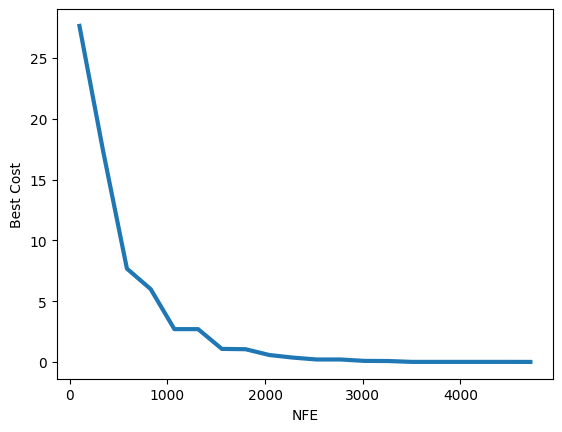

In [71]:
plt.plot(nfe, bestCosts, linewidth = 3)
plt.xlabel('NFE')
plt.ylabel('Best Cost')

### y-axis in logarithm

Text(0, 0.5, 'Best Cost')

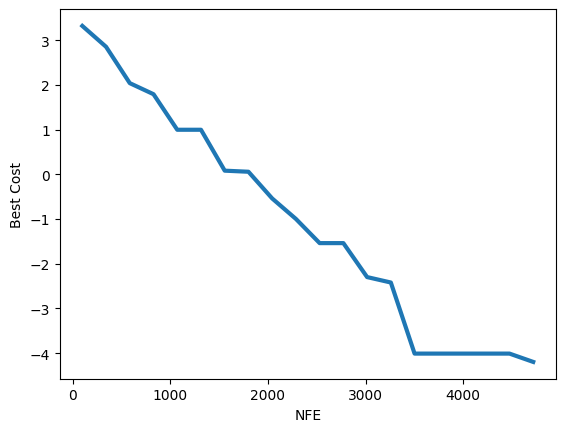

In [72]:
plt.plot(nfe, np.log(bestCosts), linewidth = 3)
plt.xlabel('NFE')
plt.ylabel('Best Cost')